### **데이터 탐색**

In [14]:
# 라이브러리 호출
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import ast
import json

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 컬럼 너비 제한 해제
pd.set_option('display.max_colwidth', None)

---
#### **데이터 로드**

In [15]:
df_Platinum_Match = pd.read_csv('./tft_game_dataset/TFT_Platinum_MatchData.csv')
df_Diamond_Match = pd.read_csv('./tft_game_dataset/TFT_Diamond_MatchData.csv')
df_Master_Match = pd.read_csv('./tft_game_dataset/TFT_Master_MatchData.csv')
df_GrandMaster_Match = pd.read_csv('./tft_game_dataset/TFT_GrandMaster_MatchData.csv')
df_Challenger_Match = pd.read_csv('./tft_game_dataset/TFT_Challenger_MatchData.csv')

df_Champion_info = pd.read_csv('./tft_game_dataset/TFT_Champion_CurrentVersion.csv')
df_Items_info = pd.read_csv('./tft_game_dataset/TFT_Item_CurrentVersion.csv')


In [22]:
tables = {
    'Platinum': df_Platinum_Match,
    'Diamond': df_Diamond_Match,
    'Master': df_Master_Match,
    'GrandMaster': df_GrandMaster_Match,
    'Challenger': df_Challenger_Match,
}

def sort_and_nunique(tables, target_col):
    for name, df in tables.items():
        df_copy = df.copy()
        df_copy[f'{target_col}_sorted'] = df_copy[target_col].apply(
            # ast.literal_eval: 문자열이 생긴 모양을 보고 내부적으로 데이터형을 변환
            # dict는 nunique() 사용 불가(unhashable)하므로 다시 문자열로 변환
            # ensure_ascii=False : 한글 등 유니코드 문자 깨짐 방지
            lambda x: json.dumps(dict(sorted(ast.literal_eval(x).items())), ensure_ascii=False)
        )
        print(f"=== {name} ===")
        # 키와 값이 완전히 동일할 때, 같은 범주로 묶임
        print(f"  [{target_col}] 고유값 개수(key값 기준 오름차순 정렬 후): {df_copy[f'{target_col}_sorted'].nunique()}")
        print()

sort_and_nunique(tables, 'combination')

=== Platinum ===
  [combination] 고유값 개수(key값 기준 오름차순 정렬 후): 36884

=== Diamond ===
  [combination] 고유값 개수(key값 기준 오름차순 정렬 후): 33168

=== Master ===
  [combination] 고유값 개수(key값 기준 오름차순 정렬 후): 26452

=== GrandMaster ===
  [combination] 고유값 개수(key값 기준 오름차순 정렬 후): 26397

=== Challenger ===
  [combination] 고유값 개수(key값 기준 오름차순 정렬 후): 22960



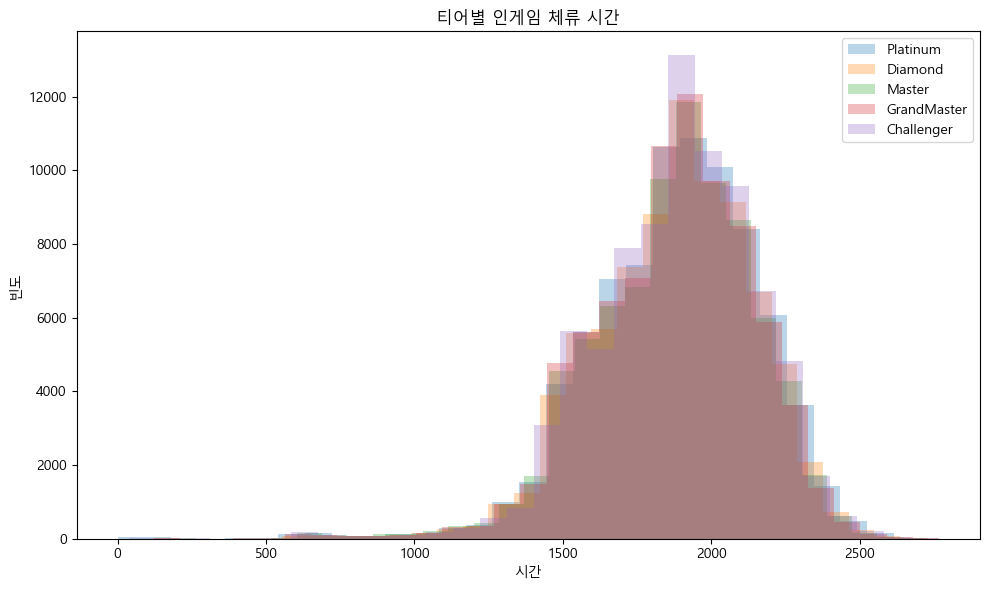

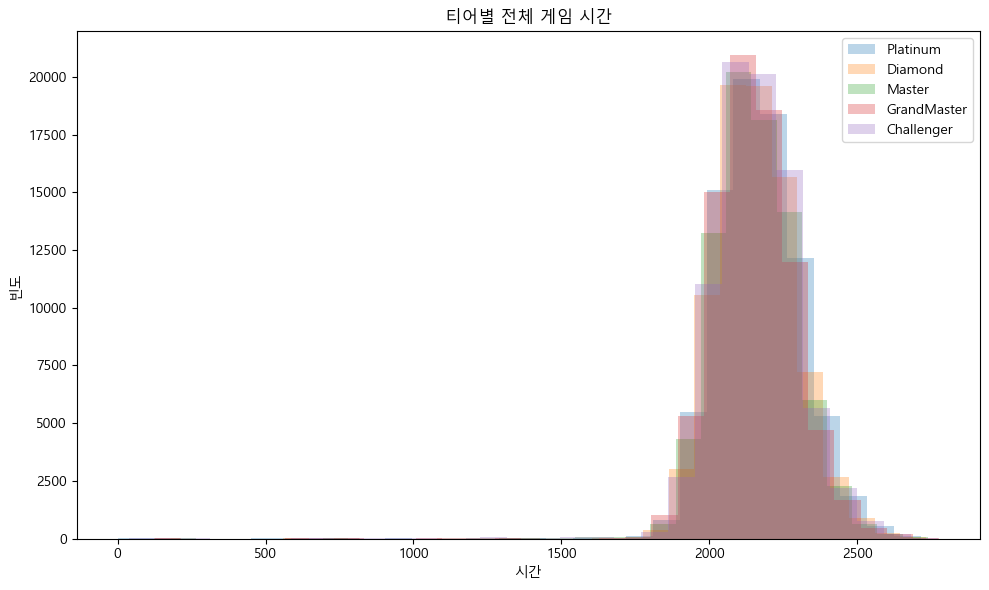

In [24]:
def plot_hist_overlay(tables, col, title=None, xlabel=None):
    plt.figure(figsize=(10, 6))

    for name, df in tables.items():
        plt.hist(df[col], bins=30, alpha=0.3, label=name)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('빈도')
    plt.legend()
    plt.tight_layout()
    plt.show()

# 사용법
plot_hist_overlay(tables, 'ingameDuration', title='티어별 인게임 체류 시간', xlabel='시간')
plot_hist_overlay(tables, 'gameDuration', title='티어별 전체 게임 시간', xlabel='시간')

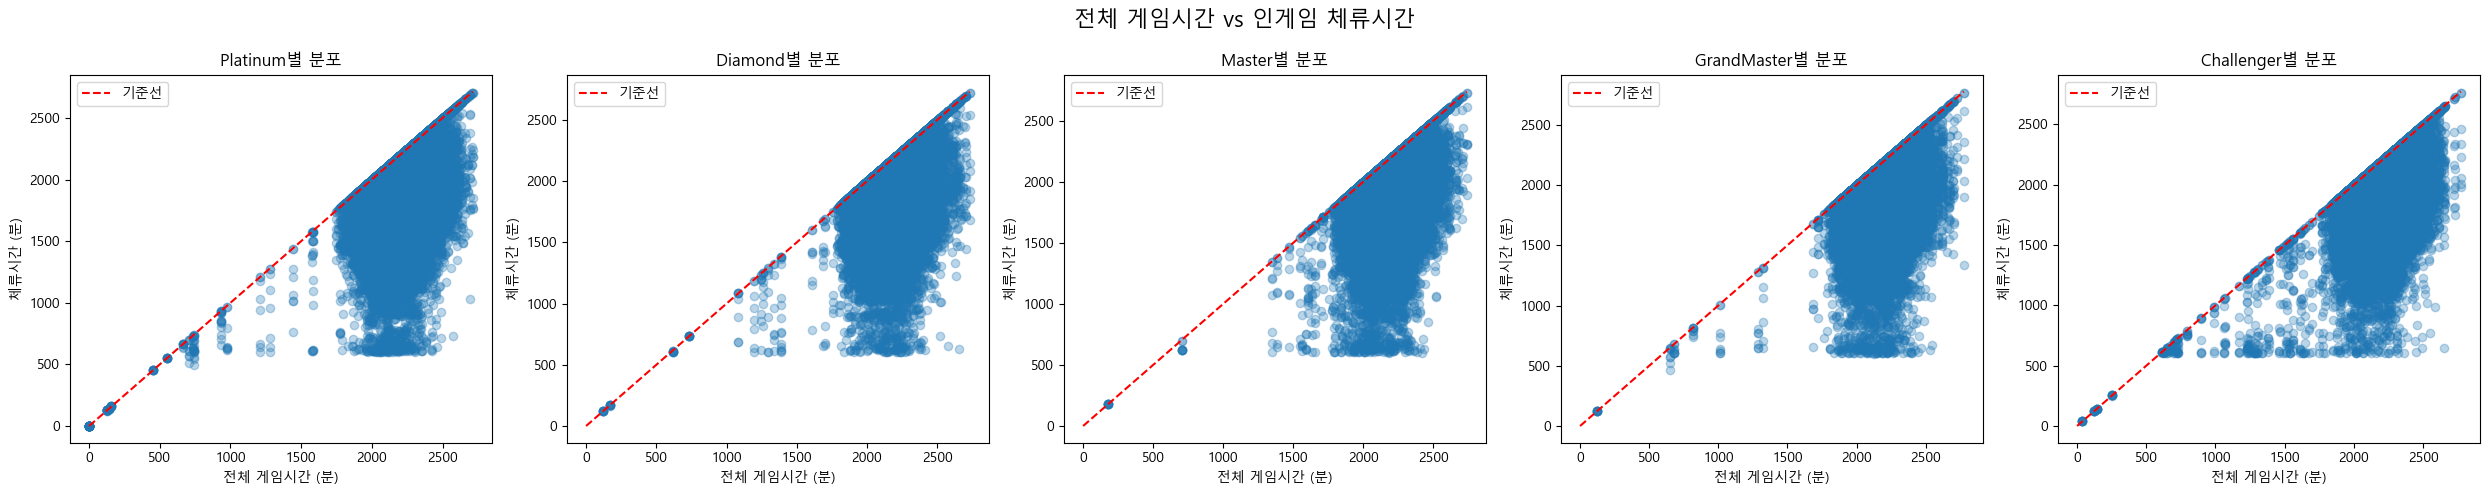

In [26]:
def plot_scatter_all(tables, x_col, y_col, title=None, xlabel=None, ylabel=None):
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    fig.suptitle(title, fontsize=16)

    for i, (name, df) in enumerate(tables.items()):
        # x=y라는 기준선을 그리기 위해 작성
        # df[x_col].max() - 전체 게임시간의 최댓값
        # df[y_col].max() - 체류시간의 최댓값
        max_val = max(df[x_col].max(), df[y_col].max())
        
        axes[i].scatter(df[x_col], df[y_col], alpha=0.3) # 산점도
        axes[i].plot([0, max_val], [0, max_val], 'r--', label='기준선') # 기준선
        axes[i].set_title(f"{name}별 분포")
        axes[i].set_xlabel(xlabel)
        axes[i].set_ylabel(ylabel)
        axes[i].legend()

    plt.tight_layout()
    plt.show()

# 사용법
plot_scatter_all(tables, 'gameDuration', 'ingameDuration', 
                title='전체 게임시간 vs 인게임 체류시간', 
                xlabel='전체 게임시간 (분)', 
                ylabel='체류시간 (분)')

In [28]:
for name, df in tables.items():
    anomaly = df[df['ingameDuration'] > df['gameDuration']]
    zero_game = df[df['gameDuration'] == 0]
    print(f"=== {name} 티어 ===")
    print(f"인게임 체류시간 > 전체 게임시간: {len(anomaly)}개")
    print(f"전체 게임시간 = 0: {len(zero_game)}개")
    print()

=== Platinum 티어 ===
인게임 체류시간 > 전체 게임시간: 0개
전체 게임시간 = 0: 32개

=== Diamond 티어 ===
인게임 체류시간 > 전체 게임시간: 0개
전체 게임시간 = 0: 0개

=== Master 티어 ===
인게임 체류시간 > 전체 게임시간: 0개
전체 게임시간 = 0: 0개

=== GrandMaster 티어 ===
인게임 체류시간 > 전체 게임시간: 0개
전체 게임시간 = 0: 0개

=== Challenger 티어 ===
인게임 체류시간 > 전체 게임시간: 0개
전체 게임시간 = 0: 0개



In [30]:
# 전체 게임 시간이 0인 행만 남긴 뒤, 거기서 게임ID 컬럼만 가져옴 -> 고유값을 정리
zero_games = df_Platinum_Match[df_Platinum_Match['gameDuration'] == 0]['gameId'].unique()

print(f"게임시간 = 0인 고유 게임 수: {len(zero_games)}")
print(f"게임시간 = 0인 고유 게임 목록: {zero_games}")
print(f"게임시간이 0인 유저의 수: {len(zero_games) * 8}")

게임시간 = 0인 고유 게임 수: 4
게임시간 = 0인 고유 게임 목록: <StringArray>
['KR_3890408252', 'KR_3891808329', 'KR_3891442705', 'KR_3891371111']
Length: 4, dtype: str
게임시간이 0인 유저의 수: 32


In [36]:
# 시즌 2 고유 시너지 목록
season2_keys = {'Alchemist', 'Avatar', 'Berserker',
                'Crystal', 'Desert', 'Druid', 'Electric',
                'Light', 'Mage', 'Mountain', 'Mystic', 'Ocean',
                'Poison', 'Predator', 'Set2_Assassin', 'Set2_Blademaster',
                'Set2_Glacial', 'Set2_Ranger', 'Shadow', 'Soulbound',
                'Summoner', 'Warden', 'Wind', 'Woodland'}  # 시즌 2 시너지 입력

# 시즌 2 시너지가 하나라도 포함되면 시즌 2로 분류
for name, df in tables.items():
    df_copy2 = df.copy()
    df_copy2['season'] = df_copy2['combination'].apply(
        lambda x: 'season 2' if any(k in season2_keys for k in ast.literal_eval(x).keys())
        else 'season 3'
    )
    
    print(f"=== {name} ===")
    print(df_copy2['season'].value_counts())
    print(round((df_copy2['season'].value_counts(normalize=True)*100),3))  # 비율(%)
    print()

=== Platinum ===
season
season 3    77186
season 2     2814
Name: count, dtype: int64
season
season 3    96.482
season 2     3.517
Name: proportion, dtype: float64

=== Diamond ===
season
season 3    79584
season 2      416
Name: count, dtype: int64
season
season 3    99.48
season 2     0.52
Name: proportion, dtype: float64

=== Master ===
season
season 3    79999
Name: count, dtype: int64
season
season 3    100.0
Name: proportion, dtype: float64

=== GrandMaster ===
season
season 3    80000
Name: count, dtype: int64
season
season 3    100.0
Name: proportion, dtype: float64

=== Challenger ===
season
season 3    79999
Name: count, dtype: int64
season
season 3    100.0
Name: proportion, dtype: float64



In [37]:
total_rows = 0
total_season2 = 0

for name, df in tables.items():
    df_copy3 = df.copy()
    df_copy3['season'] = df_copy3['combination'].apply(
        lambda x: 'season2' if any(k in season2_keys for k in ast.literal_eval(x).keys())
        else 'season3'
    )
    total_rows += len(df_copy3)
    total_season2 += (df_copy3['season'] == 'season2').sum()

print(f"전체 행 수: {total_rows}")
print(f"season2 행 수: {total_season2}")
print(f"season2 비율: {round(total_season2 / total_rows * 100, 3)}%")

전체 행 수: 399998
season2 행 수: 3230
season2 비율: 0.808%
